<a href="https://colab.research.google.com/github/haf5th/PCVK_Ganjil2026/blob/main/Pertemuan_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, datetime, zoneinfo, hashlib

NAMA = 'Hafif Nurrahmad'
NIM = ' 244107020176'  # ganti dengan NIM Anda
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y%m%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Hafif Nurrahmad
NIM :  244107020176 | N = 176
bins   : 8
clip   : 1.5
tile   : 2
L      : 8
WAKTU : 2026-10-08 22:35:57 WIB
SISTEM: 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 21ba611567a93481


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import glob

DIR = '/content/drive/MyDrive/PCVK'
LENA = DIR + '/lena.jpeg'
KTM  = DIR + '/ktm.jpeg'

**PRAKTIKUM 1**

<BarContainer object of 256 artists>

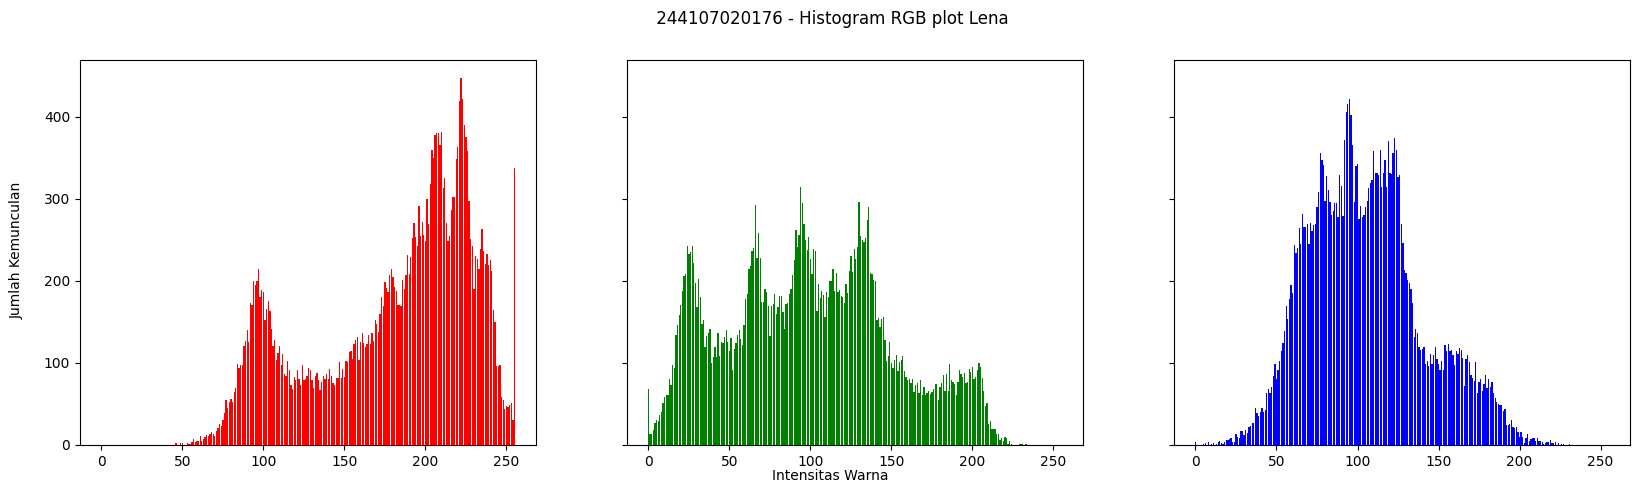

In [5]:
#membuat histogram image (manual) - Lena
img = cv.imread(LENA)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot Lena')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

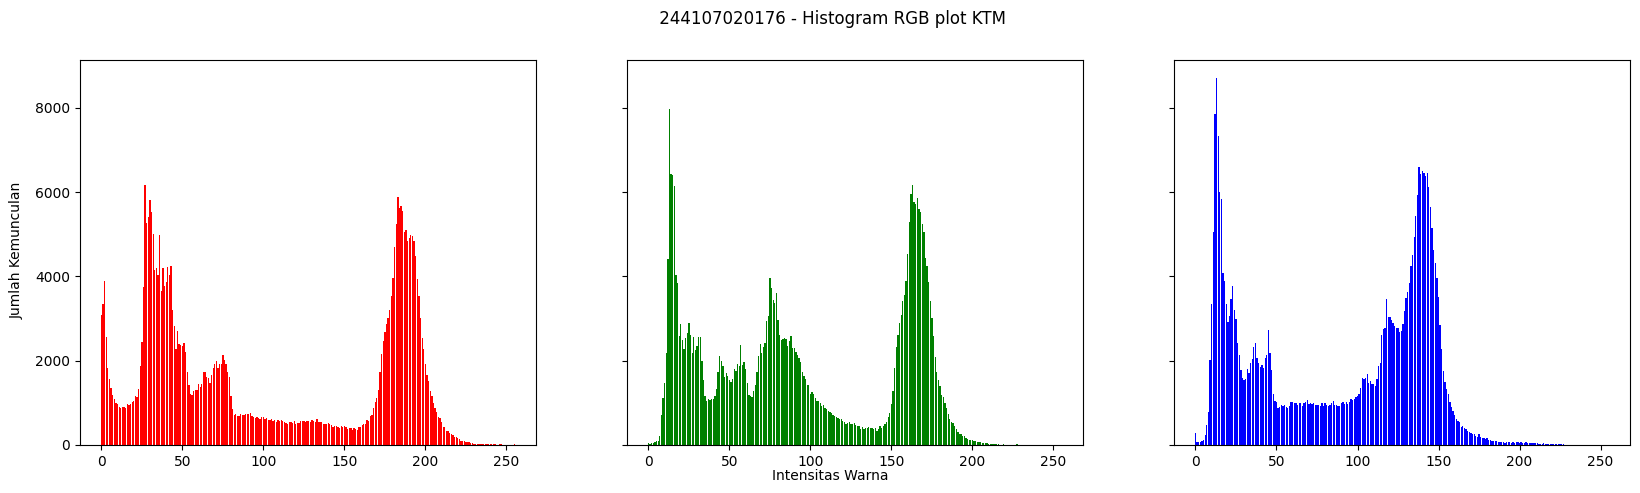

In [6]:
#membuat histogram image (manual) - KTM
img = cv.imread(KTM)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot KTM')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**TUGAS PRAKTIKUM 1**

**1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada ktm.jpg**

In [7]:
def histogram_manual(img):
    histogram = np.zeros(256, dtype=np.int64)

    for nilai in img.ravel():
        histogram[nilai] += 1

    return histogram

def cek_histogram(file_gambar):
    image = cv.imread(file_gambar)

    if image is None:
        print('Gambar tidak ditemukan')
        return

    kanal = {
        'Biru': image[:, :, 0],
        'Hijau': image[:, :, 1],
        'Merah': image[:, :, 2]
    }

    for nama, data in kanal.items():
        manual = histogram_manual(data)
        numpy_histogram, _ = np.histogram(data, bins=256, range=(0, 256))
        opencv_histogram = cv.calcHist([data], [0], None, [256], [0, 256]).reshape(256).astype(np.int64)
        beda_numpy = np.max(np.abs(manual - numpy_histogram))
        beda_opencv = np.max(np.abs(manual - opencv_histogram))
        print(nama, '| Manual-NumPy:', beda_numpy, '| Manual-OpenCV:', beda_opencv)

print('Hasil lena.jpeg')
cek_histogram(LENA)

print('\nHasil ktm.jpeg')
cek_histogram(KTM)

Hasil lena.jpeg
Biru | Manual-NumPy: 0 | Manual-OpenCV: 0
Hijau | Manual-NumPy: 0 | Manual-OpenCV: 0
Merah | Manual-NumPy: 0 | Manual-OpenCV: 0

Hasil ktm.jpeg
Biru | Manual-NumPy: 0 | Manual-OpenCV: 0
Hijau | Manual-NumPy: 0 | Manual-OpenCV: 0
Merah | Manual-NumPy: 0 | Manual-OpenCV: 0


**Jawab:** Selisih maksimum antara histogram manual, `numpy.histogram`, dan `cv.calcHist` bernilai **0** pada ketiga kanal (B, G, R) baik untuk Lena maupun KTM. Artinya ketiga cara menghitung jumlah kemunculan tiap intensitas secara identik; perbedaannya hanya pada kecepatan (manual dengan loop Python paling lambat).

**2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk citra KTM dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2.**

> Catatan: hanya tersedia satu berkas `ktm.jpeg`, sehingga empat kondisi pencahayaan (asli, gelap, terang, kontras rendah) **disimulasikan** dari citra tersebut menggunakan koreksi gamma / penskalaan kontras. Jika Anda punya empat foto asli dari Pertemuan 2, ganti isi dictionary `varian` dengan hasil `cv.imread` masing-masing.

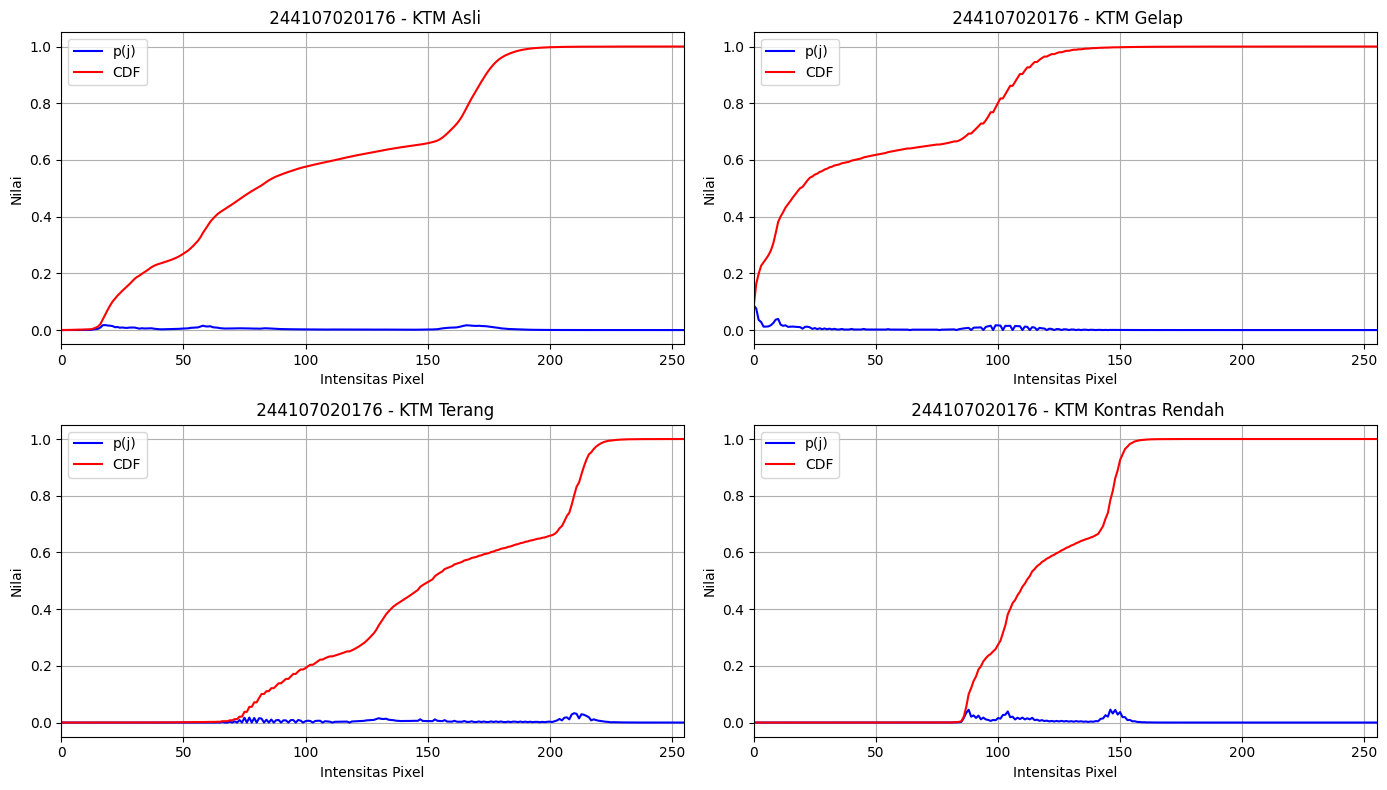

In [8]:
def histogram_manual(img):
    h = np.zeros(256, dtype=np.int64)

    for nilai in img.ravel():
        h[nilai] += 1

    return h

def gamma_koreksi(gray, g):
    tabel = np.uint8(255 * (np.arange(256) / 255) ** g)
    return tabel[gray]

gray_ktm = cv.imread(KTM, cv.IMREAD_GRAYSCALE)

varian = {
    'KTM Asli'          : gray_ktm,
    'KTM Gelap'         : gamma_koreksi(gray_ktm, 2.2),
    'KTM Terang'        : gamma_koreksi(gray_ktm, 0.45),
    'KTM Kontras Rendah': cv.convertScaleAbs(gray_ktm, alpha=0.4, beta=80),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (nama, gray) in zip(axes.ravel(), varian.items()):
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)

    ax.plot(p, color='blue', label='p(j)')
    ax.plot(cdf, color='red', label='CDF')
    ax.set_title(NIM + ' - ' + nama)
    ax.set_xlabel('Intensitas Pixel')
    ax.set_ylabel('Nilai')
    ax.set_xlim(0, 255)
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

**Jawab:** Pada citra paling gelap, massa histogram menumpuk di intensitas rendah sehingga kurva CDF naik sangat tajam di sisi kiri dan sudah mendekati 1 sebelum pertengahan skala. Pada citra paling terang kejadiannya kebalikannya: CDF tetap mendekati 0 sampai intensitas tinggi lalu naik tajam di sisi kanan. Kondisi ini berkaitan dengan pencahayaan saat akuisisi pada Pertemuan 2: foto yang diambil dengan cahaya kurang (atau eksposur rendah) menggeser histogram ke kiri, sedangkan cahaya berlebih menggesernya ke kanan.

**3. Ulangi histogram ktm.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.**

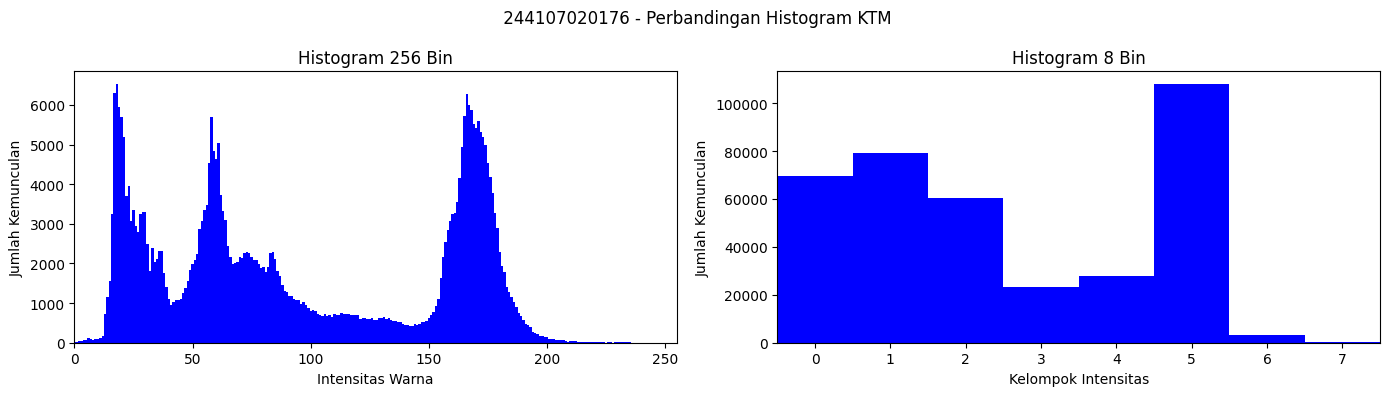

In [9]:
gray = cv.imread(KTM, cv.IMREAD_GRAYSCALE)

hist_256, _ = np.histogram(gray, bins=256, range=(0, 256))
hist_n, _ = np.histogram(gray, bins=PARAM['bins'], range=(0, 256))

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(NIM + ' - Perbandingan Histogram KTM')

axs[0].bar(np.arange(256), hist_256, color='blue', width=1)
axs[0].set_title('Histogram 256 Bin')
axs[0].set_xlabel('Intensitas Warna')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].set_xlim(0, 255)

axs[1].bar(np.arange(PARAM['bins']), hist_n, color='blue', width=1)
axs[1].set_title('Histogram ' + str(PARAM['bins']) + ' Bin')
axs[1].set_xlabel('Kelompok Intensitas')
axs[1].set_ylabel('Jumlah Kemunculan')
axs[1].set_xlim(-0.5, PARAM['bins'] - 0.5)

plt.tight_layout()
plt.show()

**Jawab:** Dengan `PARAM['bins'] = 8`, setiap bin mewakili 32 level intensitas yang digabung. Yang hilang adalah detail halus distribusi: puncak-puncak sempit, celah (nilai intensitas yang tidak muncul), dan lonjakan akibat kuantisasi/kompresi tidak lagi terlihat. Bentuk umum sebaran (gelap atau terang) masih terbaca, tetapi histogram tidak lagi cukup presisi untuk dasar operasi seperti ekualisasi.

**PRAKTIKUM 2**

In [10]:
def histogram_manual(img):
    h = np.zeros(256, dtype=int)

    for nilai in img.ravel():
        h[nilai] += 1

    return h


def equalize(channel):
    h = histogram_manual(channel)
    cdf = np.cumsum(h) / channel.size
    return np.uint8(np.round(cdf * 255))[channel]

def tampilkan_equalization(bgr, judul):
    asli = cv.split(bgr)
    hasil = [equalize(channel) for channel in asli]

    warna = ['blue', 'green', 'red']
    nama = ['Biru', 'Hijau', 'Merah']

    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    fig.suptitle(NIM + ' - ' + judul)

    axs[0, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axs[0, 0].set_title('Citra Sebelum')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(cv.cvtColor(cv.merge(hasil), cv.COLOR_BGR2RGB))
    axs[0, 1].set_title('Citra Sesudah')
    axs[0, 1].axis('off')

    axs[0, 2].axis('off')

    for i in range(3):
        axs[1, i].bar(range(256), histogram_manual(asli[i]), color=warna[i])
        axs[1, i].set_title('Sebelum - ' + nama[i])
        axs[1, i].set_xlim(0, 255)

        axs[2, i].bar(range(256), histogram_manual(hasil[i]), color=warna[i])
        axs[2, i].set_title('Sesudah - ' + nama[i])
        axs[2, i].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

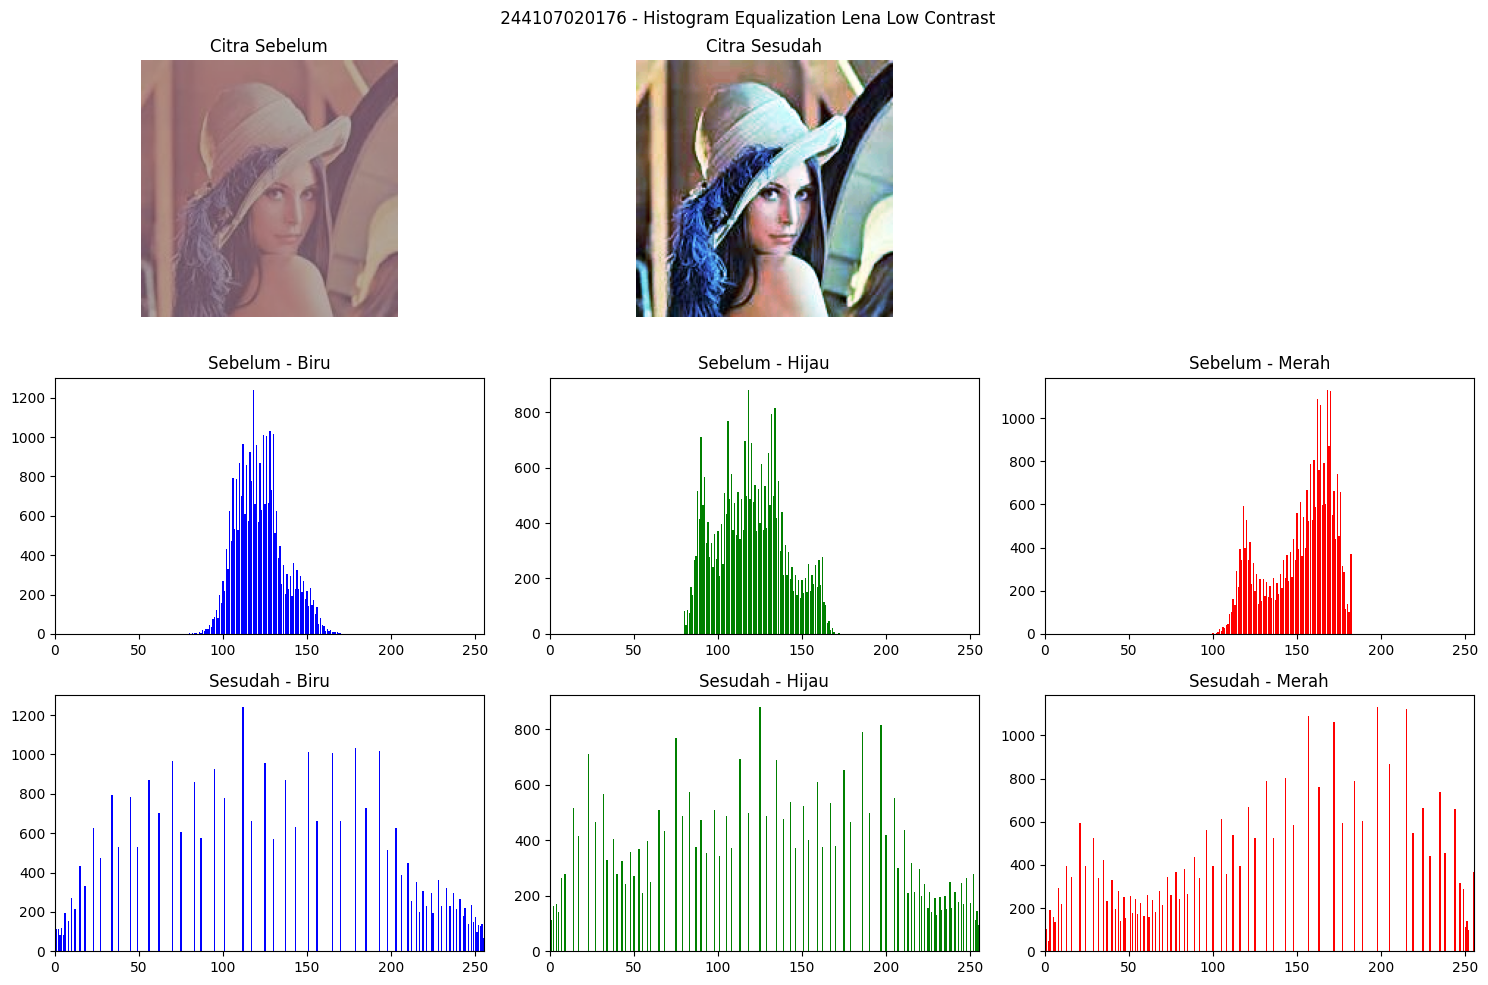

In [11]:
#lena low contrast (dibuat dari Lena dengan menekan rentang intensitas)
lena_bgr = cv.imread(LENA)
lena_lc = cv.convertScaleAbs(lena_bgr, alpha=0.4, beta=80)
tampilkan_equalization(lena_lc, 'Histogram Equalization Lena Low Contrast')

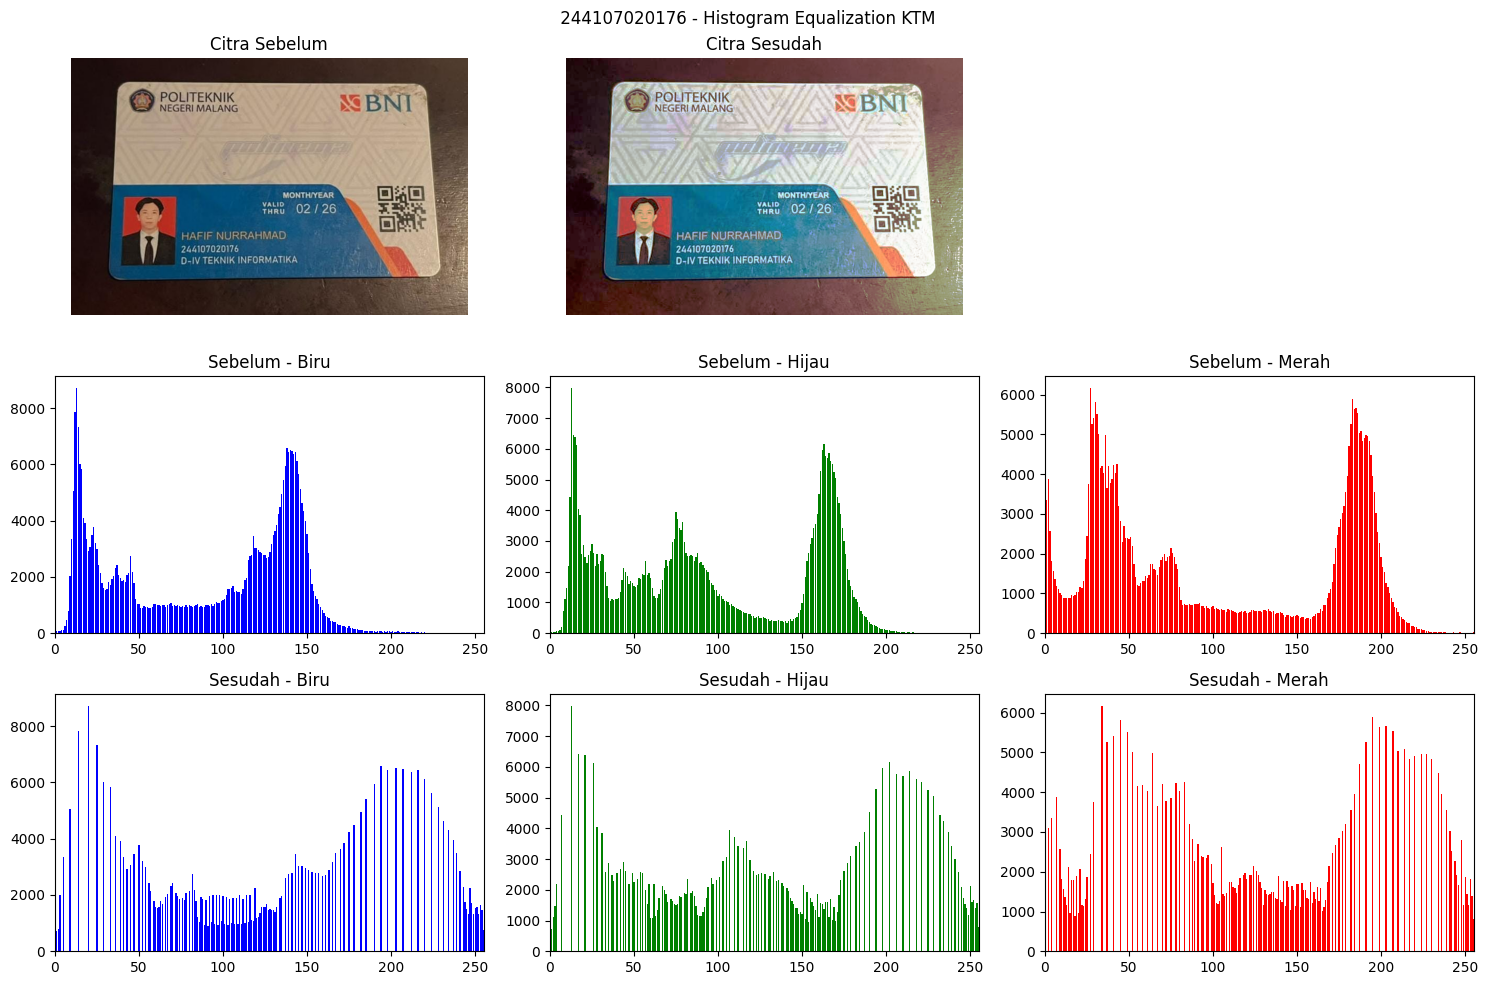

In [12]:
#KTM
ktm_bgr = cv.imread(KTM)
tampilkan_equalization(ktm_bgr, 'Histogram Equalization KTM')

In [13]:
def equalize_manual_bgr(bgr):
    b, g, r = cv.split(bgr)

    return cv.merge([
        equalize(b),
        equalize(g),
        equalize(r)
    ])

def bandingkan_equalize(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)
    hasil_manual = equalize_manual_bgr(bgr)

    b, g, r = cv.split(bgr)
    hasil_cv = cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])

    selisih = np.max(np.abs(hasil_manual.astype(int) - hasil_cv.astype(int)))

    print(f'{nama_file}: selisih maksimum manual vs cv.equalizeHist = {selisih}')

bandingkan_equalize(LENA, 'lena.jpeg')
bandingkan_equalize(KTM, 'ktm.jpeg')

lena.jpeg: selisih maksimum manual vs cv.equalizeHist = 1
ktm.jpeg: selisih maksimum manual vs cv.equalizeHist = 2


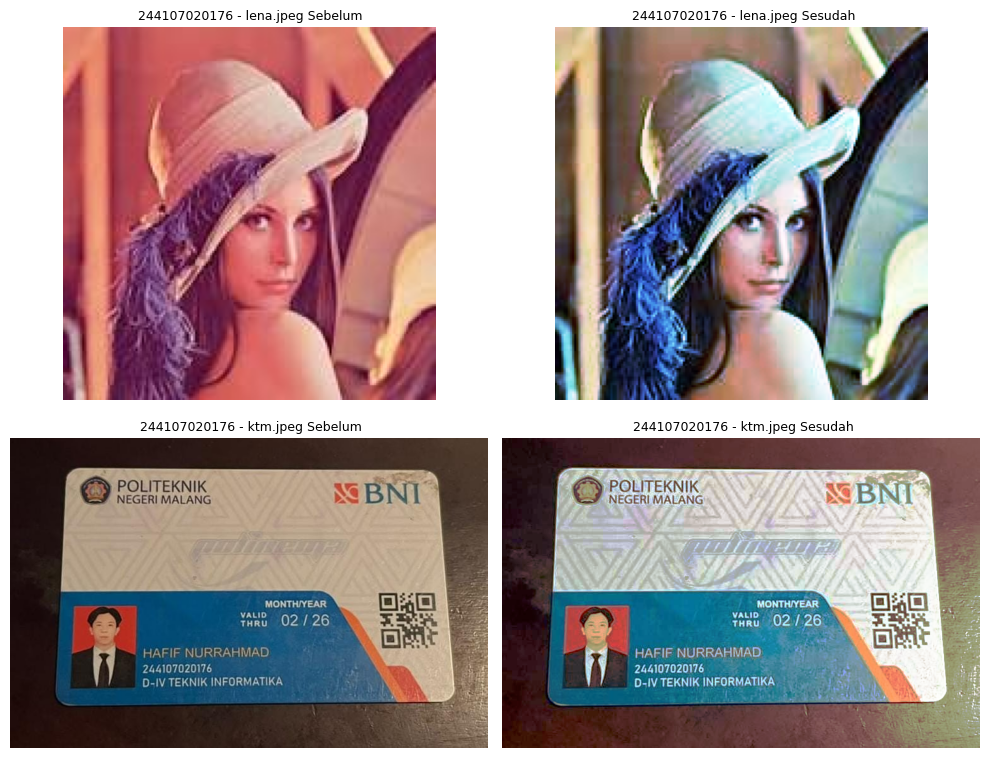

In [14]:
berkas = {'lena.jpeg': LENA, 'ktm.jpeg': KTM}

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for i, (nama_file, path) in enumerate(berkas.items()):
    bgr = cv.imread(path)

    kanal = list(cv.split(bgr))

    for j in range(3):
        kanal[j] = cv.equalizeHist(kanal[j])

    he_rgb = cv.merge(kanal)

    axs[i, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axs[i, 0].set_title(NIM + ' - ' + nama_file + ' Sebelum', fontsize=9)
    axs[i, 0].axis('off')

    axs[i, 1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
    axs[i, 1].set_title(NIM + ' - ' + nama_file + ' Sesudah', fontsize=9)
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

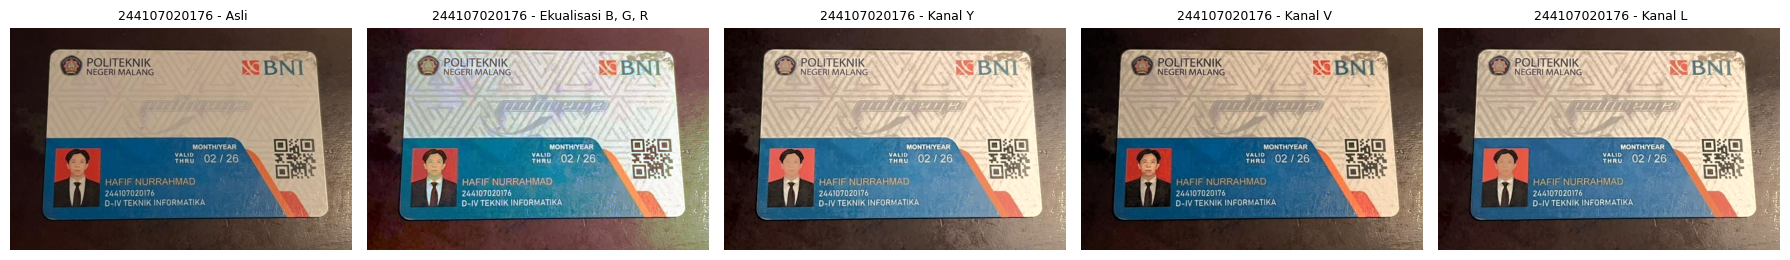

Cara                        Geser Hue    Rerata Terang
Asli                             0.00             97.1
Ekualisasi B, G, R              37.85            128.3
Kanal Y                          0.75            128.4
Kanal V                          0.70            104.6
Kanal L                          2.26            123.0


In [15]:
bgr = cv.imread(KTM)

# Equalisasi kanal B, G, dan R
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# Equalisasi kanal Y pada YCrCb
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# Equalisasi kanal V pada HSV
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# Equalisasi kanal L pada LAB
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b_lab = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_lab]), cv.COLOR_LAB2BGR)

# Daftar judul dan citra
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

# Menampilkan kelima citra
plt.figure(figsize=(18, 4))

for i, (gambar, nama) in enumerate(zip(citra, judul), start=1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + nama, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

    selisih = np.abs(h1 - h2)
    selisih = np.minimum(selisih, 180 - selisih)

    return selisih.mean() * 2

# Menampilkan hasil perhitungan
print(f'{"Cara":<24} {"Geser Hue":>12} {"Rerata Terang":>16}')

for nama, gambar in zip(judul, citra):
    terang = cv.cvtColor(gambar, cv.COLOR_BGR2GRAY).mean()
    print(f'{nama:<24} {geser_hue(bgr, gambar):>12.2f} {terang:>16.1f}')

**1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?**

**Jawab:** Metode ekualisasi kanal B, G, dan R menghasilkan pergeseran Hue paling besar, yaitu **[isi nilai dari tabel di atas]**. Hal ini terjadi karena kanal biru, hijau, dan merah diproses secara terpisah dengan tabel pemetaan yang berbeda, sehingga perbandingan antar kanal (keseimbangan warna) berubah.

**2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra dikembalikan ke ruang warna BGR.**

**Jawab:** Setelah kanal terang (Y, V, atau L) diekualisasi, citra dikonversi kembali ke BGR. Konversi ruang warna menggunakan bilangan bulat 8-bit sehingga terjadi pembulatan, dan nilai yang keluar dari rentang 0-255 dipotong (clip). Karena itu rasio antar kanal B, G, R sedikit berubah dan Hue ikut bergeser sedikit, walaupun kanal warnanya (Cr/Cb, S/H, a/b) tidak diekualisasi.

**3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? (Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian)**

**Jawab:** *(Isi setelah melihat tabel dan gambar hasil)*. Pilih kanal dengan pergeseran Hue kecil dan detail area gelap paling terbantu. Dasar penilaian: area kartu yang berisi foto, nama, NIM, dan program studi, karena bagian itulah yang perlu terbaca jelas.

**4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil ekualisasi biasa.**

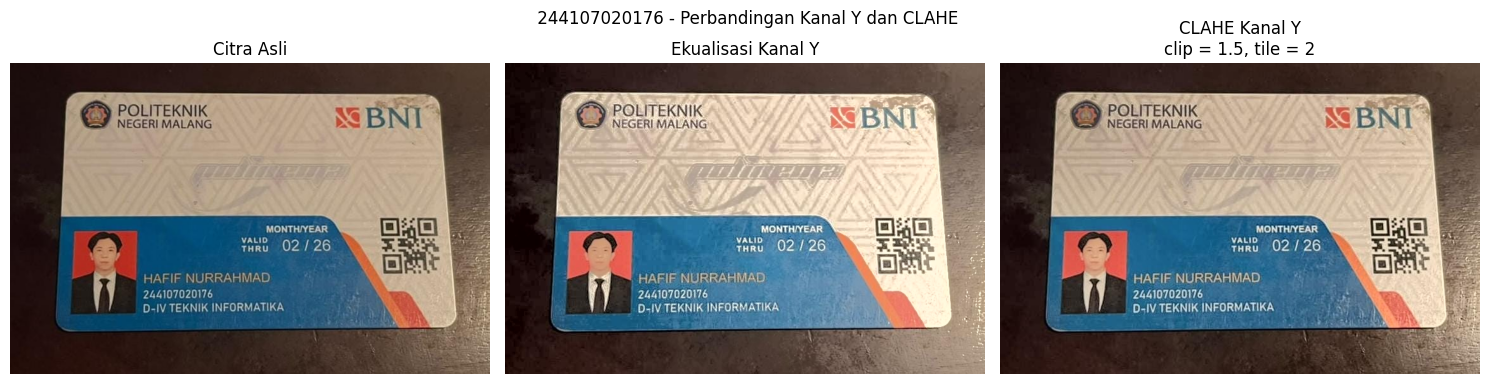

Ekualisasi Kanal Y
Geser Hue       : 0.75 derajat
Rerata kecerahan: 128.4

CLAHE Kanal Y
Geser Hue       : 0.06 derajat
Rerata kecerahan: 112.4


In [16]:
# CLAHE pada kanal Y
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

hasil_clahe = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# Menampilkan gambar
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0].set_title('Citra Asli')
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
axs[1].set_title('Ekualisasi Kanal Y')
axs[1].axis('off')

axs[2].imshow(cv.cvtColor(hasil_clahe, cv.COLOR_BGR2RGB))
axs[2].set_title('CLAHE Kanal Y\nclip = ' + str(PARAM['clip']) + ', tile = ' + str(PARAM['tile']))
axs[2].axis('off')

plt.suptitle(NIM + ' - Perbandingan Kanal Y dan CLAHE')
plt.tight_layout()
plt.show()

# Menghitung nilai pergeseran Hue dan kecerahan
print('Ekualisasi Kanal Y')
print('Geser Hue       :', round(geser_hue(bgr, he_y), 2), 'derajat')
print('Rerata kecerahan:', round(cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean(), 1))

print('\nCLAHE Kanal Y')
print('Geser Hue       :', round(geser_hue(bgr, hasil_clahe), 2), 'derajat')
print('Rerata kecerahan:', round(cv.cvtColor(hasil_clahe, cv.COLOR_BGR2GRAY).mean(), 1))

**Pertanyaan Praktikum 2**

**1. Ekualisasi global pada citra KTM Anda**

a. Terapkan ekualisasi manual dan cv.equalizeHist pada ktm.jpg versi grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

PSNR Manual: 16.82 dB
PSNR OpenCV: 16.82 dB


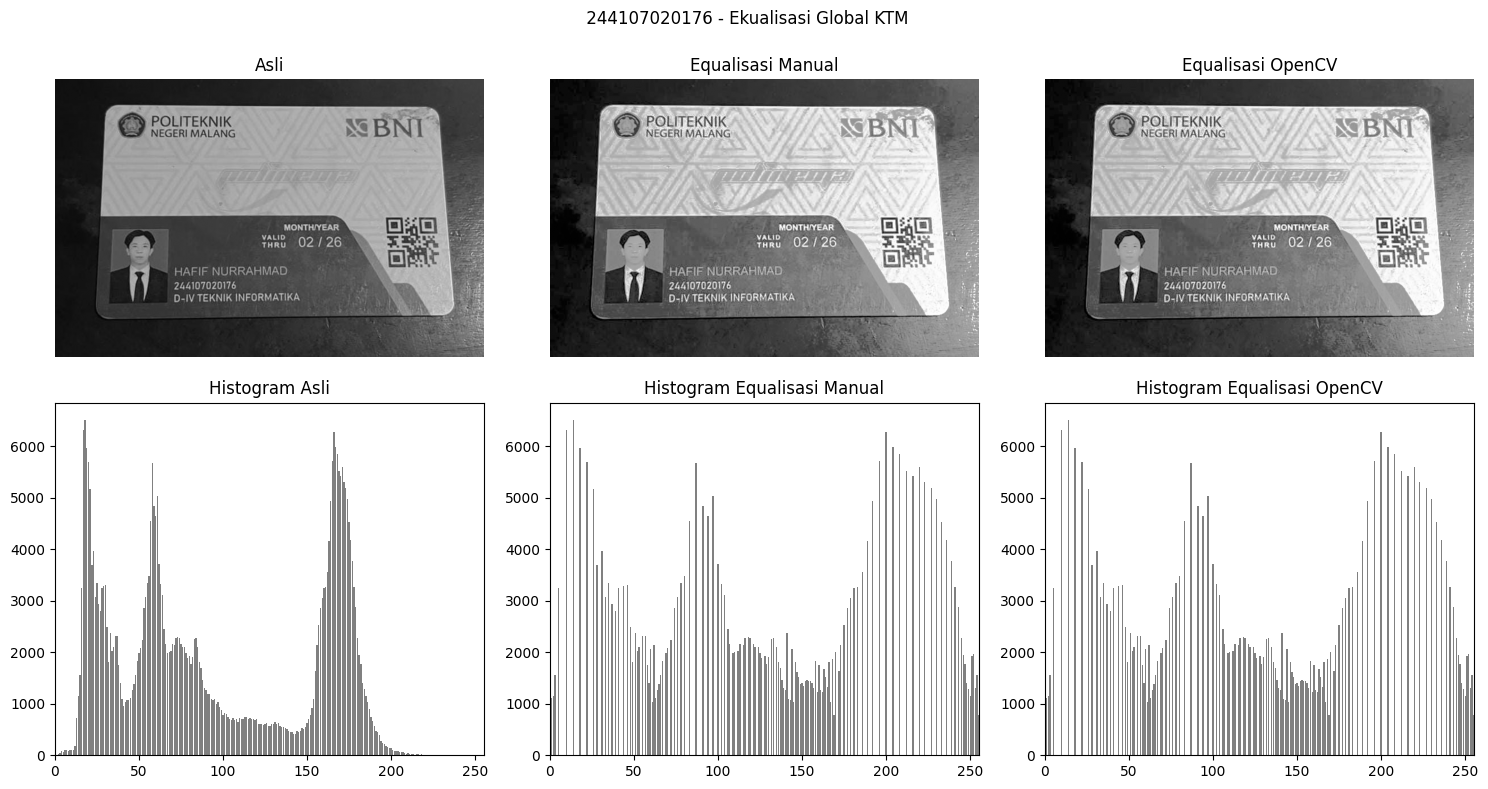

In [17]:
def equalize_manual_channel(channel):
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    tabel = np.round(cdf * 255).astype(np.uint8)

    return tabel[channel]


def hitung_psnr(asli, hasil):
    mse = np.mean((asli.astype(float) - hasil.astype(float)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255**2 / mse)

gray = cv.imread(KTM, cv.IMREAD_GRAYSCALE)

manual = equalize_manual_channel(gray)
opencv = cv.equalizeHist(gray)

print('PSNR Manual:', round(hitung_psnr(gray, manual), 2), 'dB')
print('PSNR OpenCV:', round(hitung_psnr(gray, opencv), 2), 'dB')

citra = [gray, manual, opencv]
judul = ['Asli', 'Equalisasi Manual', 'Equalisasi OpenCV']

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    axs[0, i].imshow(citra[i], cmap='gray', vmin=0, vmax=255)
    axs[0, i].set_title(judul[i])
    axs[0, i].axis('off')

    axs[1, i].bar(range(256), histogram_manual(citra[i]), color='gray')
    axs[1, i].set_title('Histogram ' + judul[i])
    axs[1, i].set_xlim(0, 255)

fig.suptitle(NIM + ' - Ekualisasi Global KTM')
plt.tight_layout()
plt.show()

**Jawab:** Histogram equalization meningkatkan kontras citra KTM. Hasil manual dan `cv.equalizeHist()` hampir identik (nilai PSNR keduanya sama atau sangat dekat: **[isi dB dari output]**), sehingga implementasi manual dianggap sesuai.

PSNR turun karena ekualisasi memang sengaja mengubah nilai piksel secara besar untuk merentangkan intensitas; PSNR hanya mengukur selisih numerik terhadap citra asli, jadi semakin banyak piksel diubah semakin kecil nilainya. PSNR tidak layak dijadikan satu-satunya ukuran keterbacaan, karena tidak mengukur kejelasan tulisan atau detail visual.

**2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda**

a. Terapkan CLAHE pada ktm.jpg dengan clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

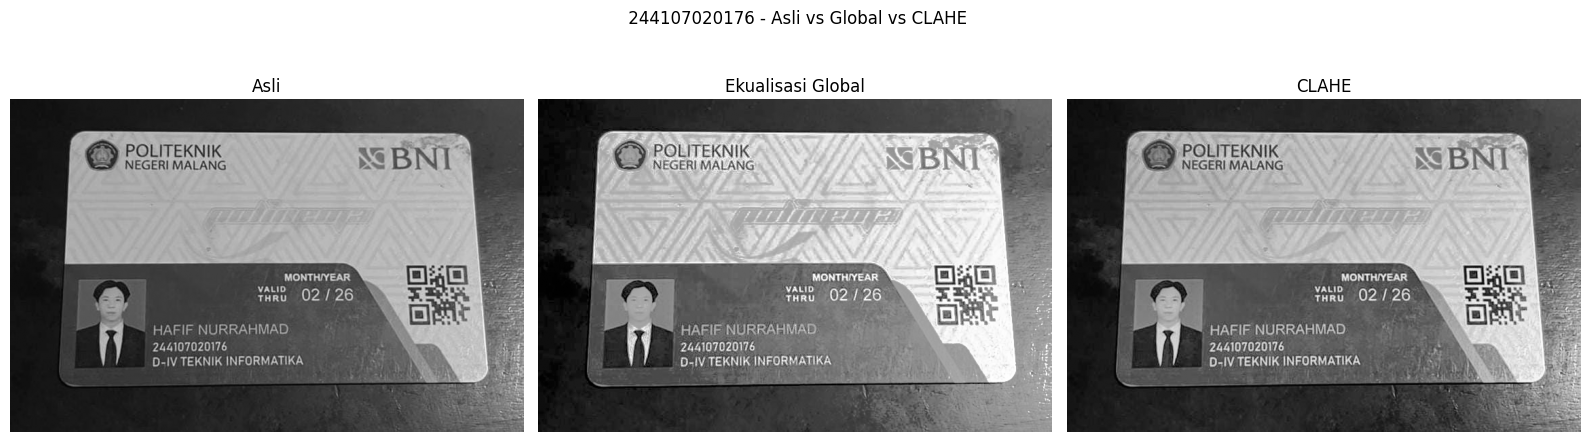

In [18]:
gray_a = cv.imread(KTM, cv.IMREAD_GRAYSCALE)
hasil_cv_a = cv.equalizeHist(gray_a)
clahe_a = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe_a = clahe_a.apply(gray_a)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(NIM + ' - Asli vs Global vs CLAHE')

axs[0].imshow(gray_a, cmap='gray')
axs[0].set_title('Asli')
axs[0].axis('off')

axs[1].imshow(hasil_cv_a, cmap='gray')
axs[1].set_title('Ekualisasi Global')
axs[1].axis('off')

axs[2].imshow(hasil_clahe_a, cmap='gray')
axs[2].set_title('CLAHE')
axs[2].axis('off')

plt.tight_layout()
plt.show()

**Jawab:** CLAHE meningkatkan kontras secara lokal per tile sehingga area kartu yang gelap menjadi lebih jelas, sedangkan ekualisasi global memakai satu pemetaan untuk seluruh citra. *(Konfirmasi dengan hasil gambar Anda: bagian nama dan NIM lebih terbaca pada hasil mana.)*

**b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan.**

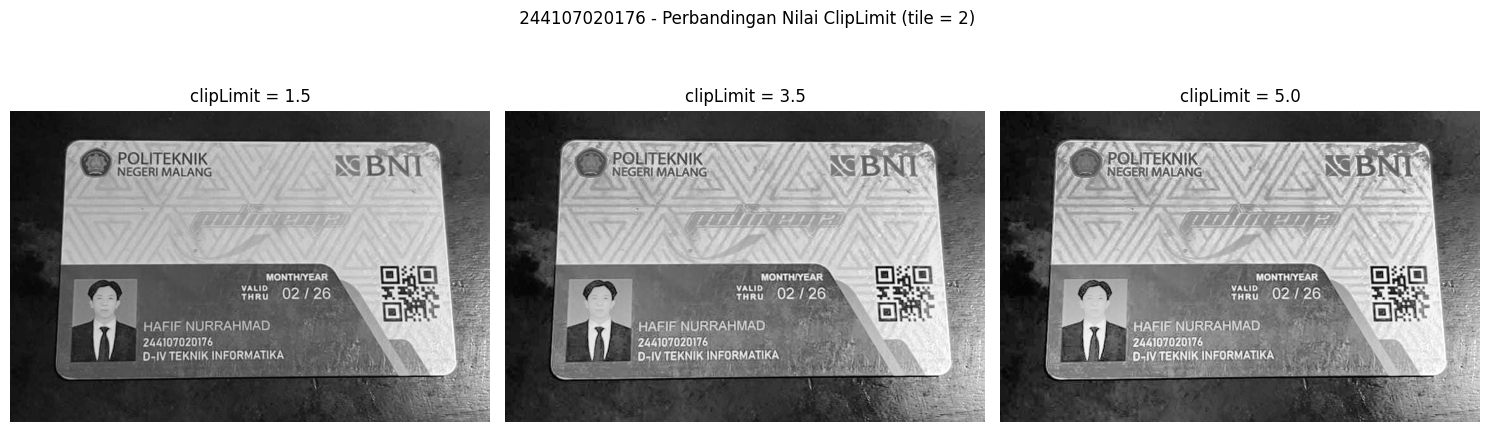

In [19]:
clip_values = [1.5, 3.5, 5.0]   # di sekitar PARAM['clip'] = 2.5

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(NIM + ' - Perbandingan Nilai ClipLimit (tile = ' + str(PARAM['tile']) + ')')

for ax, clip in zip(axs, clip_values):
    clahe = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    hasil = clahe.apply(gray_a)

    ax.imshow(hasil, cmap='gray')
    ax.set_title('clipLimit = ' + str(clip))
    ax.axis('off')

plt.tight_layout()
plt.show()

**Jawab:** Semakin kecil clipLimit, peningkatan kontras semakin lemah; semakin besar clipLimit, kontras semakin kuat tetapi noise di area gelap/rata (misalnya latar atau bagian foto yang gelap) mulai menonjol. *(Tentukan nilai terbaik dari gambar di atas, yaitu yang membuat nama dan NIM terbaca dengan noise paling sedikit.)*

**TUGAS PRAKTIKUM**

**1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada ktm.jpg dengan jumlah level PARAM['L'].**

In [20]:
def floyd_steinberg(img, L):
    hasil = img.astype(float)
    step = 255 / (L - 1)

    H, W, C = hasil.shape

    for c in range(C):
        for y in range(H):
            for x in range(W):
                lama = hasil[y, x, c]

                baru = round(lama / step) * step
                hasil[y, x, c] = baru

                error = lama - baru

                if x + 1 < W:
                    hasil[y, x + 1, c] += error * 7 / 16

                if y + 1 < H and x > 0:
                    hasil[y + 1, x - 1, c] += error * 3 / 16

                if y + 1 < H:
                    hasil[y + 1, x, c] += error * 5 / 16

                if y + 1 < H and x + 1 < W:
                    hasil[y + 1, x + 1, c] += error * 1 / 16

    return np.uint8(np.clip(hasil, 0, 255))

def tampilkan_dithering(path, judul, level):
    img = cv.imread(path)
    hasil = floyd_steinberg(img, level)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(NIM + ' - ' + judul)

    axs[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axs[0].set_title('Citra asli')
    axs[0].axis('off')

    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[1].set_title('Setelah dithering (L = ' + str(level) + ')')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

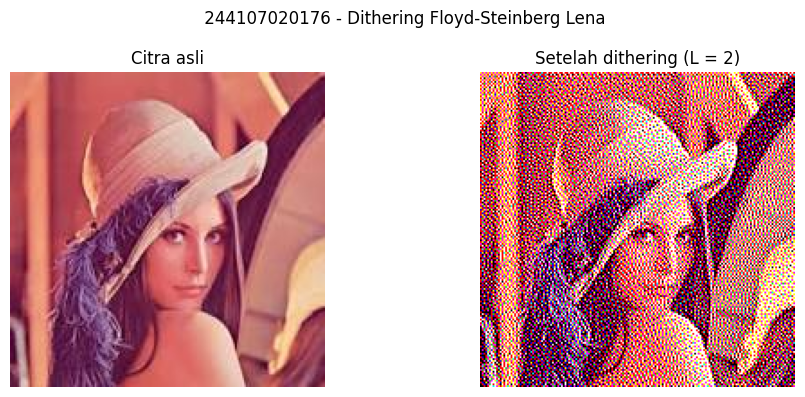

In [21]:
#lena
tampilkan_dithering(LENA, 'Dithering Floyd-Steinberg Lena', 2)

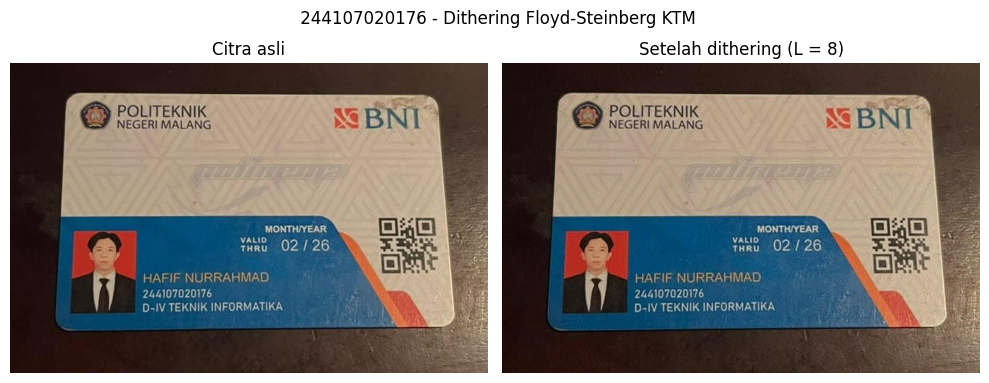

In [22]:
#KTM
tampilkan_dithering(KTM, 'Dithering Floyd-Steinberg KTM', PARAM['L'])

Dengan `PARAM['L'] = 2`, setiap channel warna hanya memiliki dua level nilai, yaitu 0 dan 255. Error dari setiap piksel disebarkan ke piksel di sekitarnya menggunakan bobot Floyd-Steinberg: 7/16 ke kanan, 3/16 ke kiri-bawah, 5/16 ke bawah, dan 1/16 ke kanan-bawah.

**2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada ktm.jpg. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.**

In [23]:
def tampilkan_perbandingan(gray, judul, level):
    img = gray
    gray_bgr = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

    dither_langsung = floyd_steinberg(gray_bgr, level)

    equalized = cv.equalizeHist(img)
    equalized_bgr = cv.cvtColor(equalized, cv.COLOR_GRAY2BGR)

    dither_setelah_equalisasi = floyd_steinberg(equalized_bgr, level)

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(NIM + ' - ' + judul)

    axs[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title('Citra grayscale')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(dither_langsung, cmap='gray', vmin=0, vmax=255)
    axs[0, 1].set_title('Dithering langsung')
    axs[0, 1].axis('off')

    axs[1, 0].imshow(equalized, cmap='gray', vmin=0, vmax=255)
    axs[1, 0].set_title('Histogram equalization')
    axs[1, 0].axis('off')

    axs[1, 1].imshow(dither_setelah_equalisasi, cmap='gray', vmin=0, vmax=255)
    axs[1, 1].set_title('Equalization lalu dithering')
    axs[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

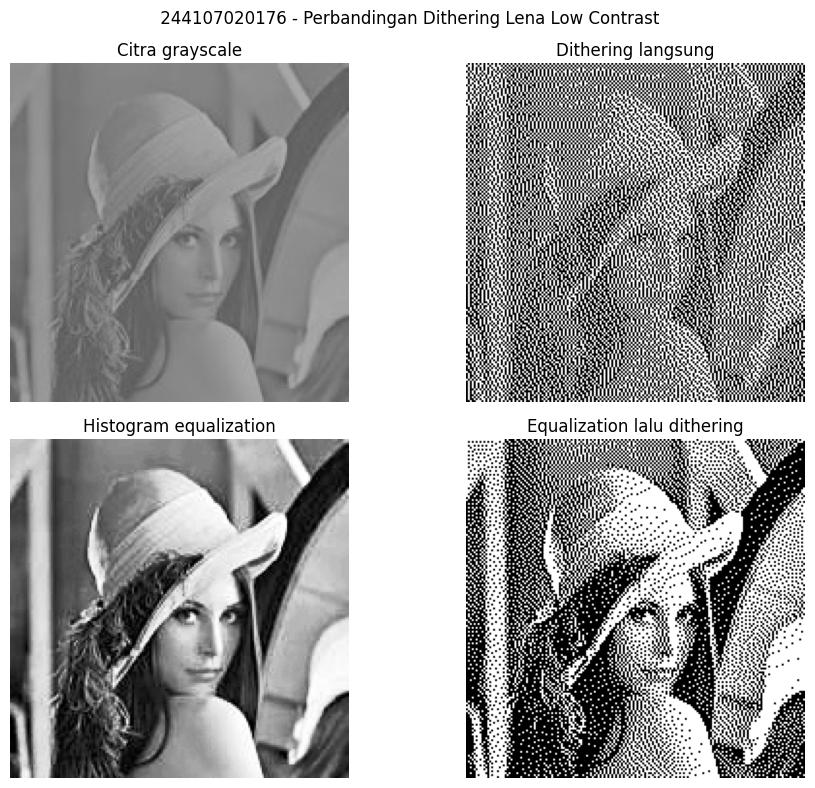

In [24]:
#lena_lc (Lena low contrast)
lena_lc_gray = cv.cvtColor(lena_lc, cv.COLOR_BGR2GRAY)
tampilkan_perbandingan(lena_lc_gray, 'Perbandingan Dithering Lena Low Contrast', 2)

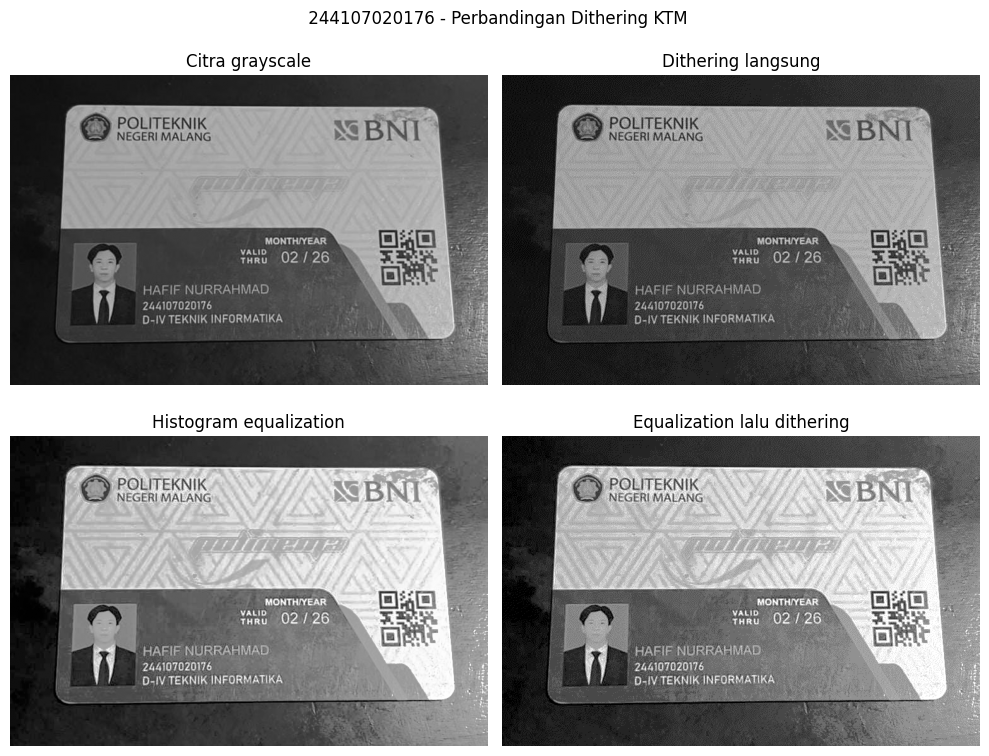

In [25]:
#KTM
tampilkan_perbandingan(cv.imread(KTM, cv.IMREAD_GRAYSCALE), 'Perbandingan Dithering KTM', PARAM['L'])

**Jawab:** Urutan histogram equalization kemudian dithering Floyd-Steinberg menghasilkan teks pada KTM yang lebih terbaca dibandingkan dithering langsung. Ekualisasi meningkatkan kontras terlebih dahulu sehingga perbedaan intensitas antara teks dan latar menjadi lebih jelas sebelum citra dikuantisasi ke `L = 2` level. Pada dithering langsung, citra yang gelap cenderung terkuantisasi menjadi hampir hitam semua sehingga teks hilang.